# 1. Dataset names and run files

In [ ]:
dataset_names = [
    "Apache", "HDFS", "HPC", "Proxifier",
    "BGL", "Hadoop", "HealthApp", "Linux",
    "Mac", "OpenSSH", "OpenStack", "Spark",
    "Thunderbird", "Zookeeper"
]

In [ ]:
# Import all the inference files
#### ....

In [ ]:
experiment_configs = {
    "Mistral_ZS": {
        "Model": "Mistral",
        "Setting": "ZS",
        "dataset_files": mistral_zs_files
    },
    "Mistral_2S": {
        "Model": "Mistral",
        "Setting": "2S",
        "dataset_files": mistral_fs_files
    },
    "Mistral_FT": {
        "Model": "Mistral",
        "Setting": "FT",
        "dataset_files": mistral_ft_files
    },
    "LLAMA_ZS": {
        "Model": "LLAMA",
        "Setting": "ZS",
        "dataset_files": llama_zs_files
    },
    "LLAMA_2S": {
        "Model": "LLAMA",
        "Setting": "2S",
        "dataset_files": llama_fs_files
    },
    "LLAMA_FT": {
        "Model": "LLAMA",
        "Setting": "FT",
        "dataset_files": llama_ft_files
    },
    "GPT_ZS": {
        "Model": "GPT",
        "Setting": "ZS",
        "dataset_files": gpt_zs_files
    },
    "GPT_2S": {
        "Model": "GPT",
        "Setting": "2S",
        "dataset_files": gpt_fs_files
    }
}

# 2. Import Variation Files

These files are used to shape the Template Families. They are frozen and provided in the GitHub repository.

In [ ]:
import pandas as pd
variation_dfs = {
    "Apache": pd.read_excel("/content/Apache.xlsx"),
    "HDFS": pd.read_excel("/content/HDFS.xlsx"),
    "HPC": pd.read_excel("/content/HPC.xlsx"),
    "Proxifier": pd.read_excel("/content/Proxifier.xlsx"),
    "BGL": pd.read_excel("/content/BGL.xlsx"),
    "Hadoop": pd.read_excel("/content/Hadoop.xlsx"),
    "HealthApp": pd.read_excel("/content/HealthApp.xlsx"),
    "Linux": pd.read_excel("/content/Linux.xlsx"),
    "Mac": pd.read_excel("/content/Mac.xlsx"),
    "OpenSSH": pd.read_excel("/content/OpenSSH.xlsx"),
    "OpenStack": pd.read_excel("/content/OpenStack.xlsx"),
    "Spark": pd.read_excel("/content/Spark.xlsx"),
    "Thunderbird": pd.read_excel("/content/Thunderbird.xlsx"),
    "Zookeeper": pd.read_excel("/content/Zookeeper.xlsx"),
}

# 3. Template normalization

In [ ]:

import re
def normalize_template(x):
    """Normalize templates before comparison."""
    if pd.isna(x):
        return None

    x = str(x)

    # Remove literal and actual new lines
    x = x.replace("\n", " ").replace("\\n", " ")

    # Remove "Extracted template:" at the beginning
    x = re.sub(
        r"^\s*Extracted\s+template\s*:\s*",
        "",
        x,
        flags=re.IGNORECASE
    )

    # Normalize placeholder variants to <*>
    x = re.sub(r"<\s*\*\s*>", "<*>", x)   # <*>, < * >
    x = re.sub(r"<\s*>", "<*>", x)        # <>
    x = re.sub(r"<\s*\?\s*>", "<*>", x)   # <?>
    x = re.sub(r"\*>", "<*>", x)          # *>

    # Normalize cases like '<*> and <*>' to '<*>'
    x = re.sub(r"'<\*>", "'<*>'", x)
    x = re.sub(r"<\*>'", "'<*>'", x)

    # Remove all whitespace: beginning, end, and inside
    x = re.sub(r"\s+", "", x)

    return x


# 4. Build template family mapping

In [ ]:
def build_template_family_mapping(variation_file, gt_col="GT Template"):
    """
    Creates a mapping where:
    EventTemplate, V1, V2, ... all map to the same canonical GT template.
    """
    variation_df = read_file(variation_file)

    variation_cols = [
        col for col in variation_df.columns
        if re.fullmatch(r"V\d+", str(col))
    ]

    mapping = {}

    for _, row in variation_df.iterrows():
        gt = normalize_template(row[gt_col])

        if gt is None:
            continue

        mapping[gt] = gt

        for col in variation_cols:
            v = normalize_template(row[col])
            if v is not None:
                mapping[v] = gt

    return mapping


def map_to_template_family(template, family_mapping):
    norm_template = normalize_template(template)
    return family_mapping.get(norm_template, norm_template)

# 5. Mark correctly parsed logs

In [ ]:
from pathlib import Path

def mark_correctly_parsed(
    variation_file,
    prediction_file,
    prediction_col,
    gt_col="GT Template",
    event_col="EventTemplate",
    output_file="marked_output.csv"
):
    # Read files
    variations_df = read_file(variation_file)
    pred_df = read_file(prediction_file)

    # Find variation columns: V1, V2, V3, ...
    variation_cols = [
        col for col in variations_df.columns
        if re.fullmatch(r"V\d+", str(col))
    ]

    # Build dictionary:
    # GT template -> acceptable templates: GT + all variations
    acceptable_templates = {}

    for _, row in variations_df.iterrows():
        gt_template = normalize_template(row[gt_col])

        accepted = {gt_template}

        for col in variation_cols:
            v = normalize_template(row[col])
            if v is not None:
                accepted.add(v)

        acceptable_templates[gt_template] = accepted

    # Check each predicted template
    correctness = []

    for _, row in pred_df.iterrows():
        event_template = normalize_template(row[event_col])
        predicted_template = normalize_template(row[prediction_col])

        accepted = acceptable_templates.get(event_template, {event_template})

        if predicted_template in accepted:
            correctness.append("Correct")
        else:
            correctness.append("Incorrect")

    # Add result column
    pred_df["AccuCheck"] = correctness

    # Save output
    pred_df.to_csv(output_file, index=False)

    return pred_df


# 6. Group Accuracy Calculation

In [ ]:
def calculate_group_accuracy(
    prediction_file,
    variation_file,
    pred_col,
    event_col="EventTemplate",
    gt_col="GT Template"
):
    """
    Group Accuracy definition:

    A GT group is correct if all log messages that belong to the same
    EventTemplate group are assigned to one same predicted group.

    Important:
    1. The predicted template does NOT need to equal the EventTemplate.
       Example: X, X, X is correct for GT group A.

    2. EventTemplate and its variations V1, V2, ... are considered the same
       predicted group.
       Example: A, V1, V2 is also correct for GT group A.
    """

    df = read_file(prediction_file)
    family_mapping = build_template_family_mapping(
        variation_file,
        gt_col=gt_col
    )

    df["_gt_norm"] = df[event_col].apply(normalize_template)
    df["_pred_norm"] = df[pred_col].apply(normalize_template)

    # Ground-truth group:
    # EventTemplate and variations are mapped to the same canonical GT template
    df["_gt_group"] = df["_gt_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    # Predicted group:
    # If prediction is EventTemplate or one of V1, V2, ...
    # map it to the canonical GT family.
    # Otherwise, keep the predicted template as its own group.
    df["_pred_group"] = df["_pred_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    correct_logs = 0
    total_logs = len(df)

    group_results = []

    for gt_group, group in df.groupby("_gt_group"):
        predicted_groups = group["_pred_group"].dropna().unique()

        is_correct_group = len(predicted_groups) == 1

        if is_correct_group:
            correct_logs += len(group)

        group_results.append({
            "GT_Group": gt_group,
            "Number_of_Logs": len(group),
            "Predicted_Groups": list(predicted_groups),
            "Is_Correct_Group": is_correct_group
        })

    group_accuracy = correct_logs / total_logs if total_logs > 0 else 0

    group_results_df = pd.DataFrame(group_results)

    return group_accuracy, group_results_df

# 7. Parsing Accuracy Calculation

In [ ]:
def calculate_parsing_accuracy(
    prediction_file,
    variation_file,
    pred_col,
    event_col="EventTemplate",
    gt_col="GT Template"
):
    df = read_file(prediction_file)

    family_mapping = build_template_family_mapping(
        variation_file,
        gt_col=gt_col
    )

    df["_gt_norm"] = df[event_col].apply(normalize_template)
    df["_pred_norm"] = df[pred_col].apply(normalize_template)

    correct_count = 0

    for _, row in df.iterrows():
        gt_group = family_mapping.get(row["_gt_norm"], row["_gt_norm"])
        pred_group = family_mapping.get(row["_pred_norm"], row["_pred_norm"])

        if pred_group == gt_group:
            correct_count += 1

    total_logs = len(df)

    parsing_accuracy = correct_count / total_logs if total_logs > 0 else 0

    return parsing_accuracy

# 8. F1 Score of Group Accuracy

In [ ]:
def calculate_fga(
    prediction_file,
    variation_file,
    pred_col,
    event_col="EventTemplate",
    gt_col="GT Template"
):
    df = read_file(prediction_file)

    family_mapping = build_template_family_mapping(
        variation_file,
        gt_col=gt_col
    )

    df["_gt_norm"] = df[event_col].apply(normalize_template)
    df["_pred_norm"] = df[pred_col].apply(normalize_template)

    # GT groups: EventTemplate and variations map to the same GT group
    df["_gt_group"] = df["_gt_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    # Predicted groups: EventTemplate and variations map to same predicted group
    df["_pred_group"] = df["_pred_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    # Ng: actual number of GT templates/groups
    Ng = df["_gt_group"].nunique(dropna=True)

    # Np: number of generated predicted templates/groups
    # after merging EventTemplate and its valid variations
    Np = df["_pred_group"].nunique(dropna=True)

    # Nc: number of correctly grouped GT templates/groups
    Nc = 0
    group_details = []

    for gt_group, group in df.groupby("_gt_group", dropna=True):
        predicted_groups = group["_pred_group"].dropna().unique()

        is_correct_group = len(predicted_groups) == 1

        if is_correct_group:
            Nc += 1

        group_details.append({
            "GT_Group": gt_group,
            "Number_of_Logs": len(group),
            "Predicted_Groups": list(predicted_groups),
            "Is_Correct_Group": is_correct_group
        })

    PGA = Nc / Np if Np > 0 else 0
    RGA = Nc / Ng if Ng > 0 else 0

    FGA = 0 if PGA + RGA == 0 else (2 * PGA * RGA) / (PGA + RGA)

    group_details_df = pd.DataFrame(group_details)

    return FGA, PGA, RGA, Nc, Np, Ng, group_details_df

# 9. F1 Score of Template Accuracy

In [ ]:
def calculate_fta(
    prediction_file,
    variation_file,
    pred_col,
    event_col="EventTemplate",
    gt_col="GT Template"
):
    df = read_file(prediction_file)

    family_mapping = build_template_family_mapping(
        variation_file,
        gt_col=gt_col
    )

    df["_gt_norm"] = df[event_col].apply(normalize_template)
    df["_pred_norm"] = df[pred_col].apply(normalize_template)

    # Ground-truth template group
    df["_gt_group"] = df["_gt_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    # Predicted template group
    # If prediction equals EventTemplate or V1/V2/... after normalization,
    # it maps to the same GT family. Otherwise, it remains itself.
    df["_pred_group"] = df["_pred_norm"].apply(
        lambda x: family_mapping.get(x, x)
    )

    # Ng: number of ground-truth templates
    Ng = df["_gt_group"].nunique(dropna=True)

    # Np: number of predicted templates after merging valid variations
    Np = df["_pred_group"].nunique(dropna=True)

    # N_hat_c: number of correctly identified templates
    N_hat_c = 0
    template_details = []

    for pred_group, group in df.groupby("_pred_group", dropna=True):

        gt_groups = group["_gt_group"].dropna().unique()

        # Condition 1:
        # All logs assigned to this predicted template share the same GT template
        same_gt_group = len(gt_groups) == 1

        # Condition 2:
        # The predicted template equals EventTemplate or one of its variations
        # This means pred_group must be the same as the only GT group
        correct_template_tokens = (
            same_gt_group and pred_group == gt_groups[0]
        )

        is_correct_template = same_gt_group and correct_template_tokens

        if is_correct_template:
            N_hat_c += 1

        template_details.append({
            "Predicted_Template_Group": pred_group,
            "Number_of_Logs": len(group),
            "GT_Groups": list(gt_groups),
            "Same_GT_Group": same_gt_group,
            "Correct_Template_Tokens": correct_template_tokens,
            "Is_Correct_Template": is_correct_template
        })

    PTA = N_hat_c / Np if Np > 0 else 0
    RTA = N_hat_c / Ng if Ng > 0 else 0

    FTA = 0 if PTA + RTA == 0 else (2 * PTA * RTA) / (PTA + RTA)

    template_details_df = pd.DataFrame(template_details)

    return FTA, PTA, RTA, N_hat_c, Np, Ng, template_details_df

# 10. Run the Pipeline

In [ ]:
def read_file(path):
    if path.endswith(".csv"):
        return pd.read_csv(path)
    elif path.endswith(".xlsx"):
        return pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")

In [ ]:
all_results = []

for experiment_name, config in experiment_configs.items():

    model = config["Model"]
    setting = config["Setting"]
    dataset_files = config["dataset_files"]

    for dataset in dataset_names:
        variation_file = f"/content/{dataset}.xlsx"

        for run_id, (file_path, pred_col) in enumerate(dataset_files[dataset], start=1):

            # marked_output_file = f"/content/{model}_{setting}_{dataset}_run_{run_id}_marked.csv"

            marked_df = mark_correctly_parsed(
                variation_file=variation_file,
                prediction_file=file_path,
                prediction_col=pred_col,
                gt_col="GT Template",
                event_col="EventTemplate",
                # output_file=marked_output_file
            )

            PA = calculate_parsing_accuracy(
                prediction_file=file_path,
                variation_file=variation_file,
                pred_col=pred_col,
                event_col="EventTemplate",
                gt_col="GT Template"
            )

            GA, group_details_df = calculate_group_accuracy(
                prediction_file=file_path,
                variation_file=variation_file,
                pred_col=pred_col,
                event_col="EventTemplate",
                gt_col="GT Template"
            )

            FGA, PGA, RGA, Nc_GA, Np_GA, Ng_GA, fga_details_df = calculate_fga(
                prediction_file=file_path,
                variation_file=variation_file,
                pred_col=pred_col,
                event_col="EventTemplate",
                gt_col="GT Template"
            )

            FTA, PTA, RTA, N_hat_c, Np_TA, Ng_TA, fta_details_df = calculate_fta(
                prediction_file=file_path,
                variation_file=variation_file,
                pred_col=pred_col,
                event_col="EventTemplate",
                gt_col="GT Template"
            )

            # group_details_file = f"/content/{model}_{setting}_{dataset}_run_{run_id}_group_details.csv"
            # fga_details_file = f"/content/{model}_{setting}_{dataset}_run_{run_id}_fga_details.csv"
            # fta_details_file = f"/content/{model}_{setting}_{dataset}_run_{run_id}_fta_details.csv"

            # group_details_df.to_csv(group_details_file, index=False)
            # fga_details_df.to_csv(fga_details_file, index=False)
            # fta_details_df.to_csv(fta_details_file, index=False)

            all_results.append({
                "Experiment": experiment_name,
                "Model": model,
                "Setting": setting,
                "Dataset": dataset,
                "Run": run_id,
                "File": file_path,
                "Prediction_Column": pred_col,

                "Parsing_Accuracy": PA,
                "Group_Accuracy": GA,

                "Nc_GA": Nc_GA,
                "Np_GA": Np_GA,
                "Ng_GA": Ng_GA,
                "PGA": PGA,
                "RGA": RGA,
                "FGA": FGA,

                "N_hat_c_TA": N_hat_c,
                "Np_TA": Np_TA,
                "Ng_TA": Ng_TA,
                "PTA": PTA,
                "RTA": RTA,
                "FTA": FTA
            })

results_df = pd.DataFrame(all_results)

results_df.to_csv("/content/all_results_all_models_settings.csv", index=False)

results_df

,Experiment,Model,Setting,Dataset,Run,File,Prediction_Column,Parsing_Accuracy,Group_Accuracy,Nc_GA,...,Ng_GA,PGA,RGA,FGA,N_hat_c_TA,Np_TA,Ng_TA,PTA,RTA,FTA
0,Mistral_ZS,Mistral,ZS,Apache,1,/content/New_Mistral_ZS_Apache_1_output_TempOn...,New_Mistral_ZS_Apache_1_TempOnly,0.560000,0.582000,5,...,6,0.714286,0.833333,0.769231,3,7,6,0.428571,0.5,0.461538
1,Mistral_ZS,Mistral,ZS,Apache,2,/content/New_Mistral_ZS_Apache_2_output_TempOn...,New_Mistral_ZS_Apache_2_TempOnly,0.560000,0.582000,5,...,6,0.714286,0.833333,0.769231,3,7,6,0.428571,0.5,0.461538
2,Mistral_ZS,Mistral,ZS,Apache,3,/content/New_Mistral_ZS_Apache_3_output_TempOn...,New_Mistral_ZS_Apache_3_TempOnly,0.560000,0.582000,5,...,6,0.714286,0.833333,0.769231,3,7,6,0.428571,0.5,0.461538
3,Mistral_ZS,Mistral,ZS,Apache,4,/content/New_Mistral_ZS_Apache_4_output_TempOn...,New_Mistral_ZS_Apache_4_TempOnly,0.560000,0.582000,5,...,6,0.714286,0.833333,0.769231,3,7,6,0.428571,0.5,0.461538
4,Mistral_ZS,Mistral,ZS,Apache,5,/content/New_Mistral_ZS_Apache_5_output_TempOn...,New_Mistral_ZS_Apache_5_TempOnly,0.560000,0.582000,5,...,6,0.714286,0.833333,0.769231,3,7,6,0.428571,0.5,0.461538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,GPT_2S,GPT,2S,Zookeeper,1,/content/Unseen_gpt_2S_Zookeeper_1_output.csv,GPT_Temp_1,0.993976,1.000000,10,...,10,1.111111,1.000000,1.052632,8,9,10,0.888889,0.8,0.842105
556,GPT_2S,GPT,2S,Zookeeper,2,/content/Unseen_gpt_2S_Zookeeper_2_output.csv,GPT_Temp_2,0.990964,0.966867,9,...,10,0.900000,0.900000,0.900000,8,10,10,0.800000,0.8,0.800000
557,GPT_2S,GPT,2S,Zookeeper,3,/content/Unseen_gpt_2S_Zookeeper_3_output.csv,GPT_Temp_3,0.993976,1.000000,10,...,10,1.111111,1.000000,1.052632,8,9,10,0.888889,0.8,0.842105
558,GPT_2S,GPT,2S,Zookeeper,4,/content/Unseen_gpt_2S_Zookeeper_4_output.csv,GPT_Temp_4,0.990964,0.966867,9,...,10,0.900000,0.900000,0.900000,8,10,10,0.800000,0.8,0.800000


# 11. Average Results Over 5 Runs

In [ ]:
average_results = results_df.groupby(
    ["Model", "Setting", "Dataset"]
)[[
    "Parsing_Accuracy",
    "Group_Accuracy",
    "PGA",
    "RGA",
    "FGA",
    "PTA",
    "RTA",
    "FTA"
]].mean().reset_index()

average_results = average_results.round(4)

average_results.to_csv("/content/average_results_all_models_settings.csv", index=False)

average_results

,Model,Setting,Dataset,Parsing_Accuracy,Group_Accuracy,PGA,RGA,FGA,PTA,RTA,FTA
0,GPT,2S,Apache,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,GPT,2S,BGL,0.9952,0.9926,0.8426,0.9250,0.8815,0.9024,0.9917,0.9446
2,GPT,2S,HDFS,0.9740,0.8081,0.3569,0.7571,0.4848,0.4712,1.0000,0.6401
3,GPT,2S,HPC,0.8784,0.6690,0.7420,0.8000,0.7699,0.8024,0.8652,0.8326
4,GPT,2S,Hadoop,0.8425,0.7868,0.5248,0.7818,0.6279,0.4452,0.6636,0.5328
...,...,...,...,...,...,...,...,...,...,...,...
107,Mistral,ZS,OpenStack,0.1294,0.1513,0.5833,0.8750,0.7000,0.4167,0.6250,0.5000
108,Mistral,ZS,Proxifier,0.1430,0.0010,0.0192,0.1250,0.0332,0.0959,0.6250,0.1662
109,Mistral,ZS,Spark,0.0000,0.5000,0.6000,0.8571,0.7059,0.0000,0.0000,0.0000
110,Mistral,ZS,Thunderbird,0.0202,0.1149,0.9000,0.9310,0.9153,0.1667,0.1724,0.1695


# Box Plots for each Metric

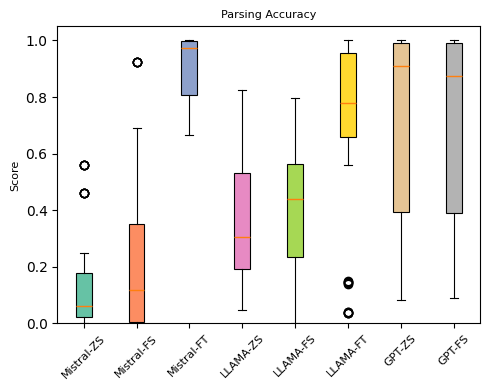

Saved: /content/Parsing_Accuracy_boxplot.png


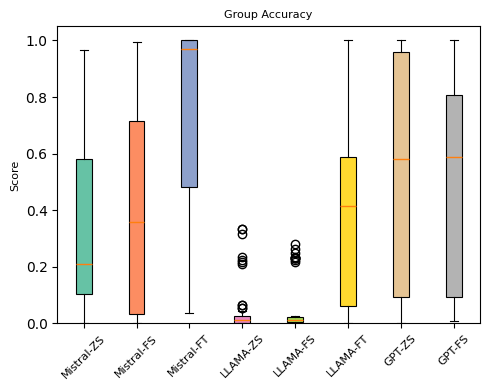

Saved: /content/Group_Accuracy_boxplot.png


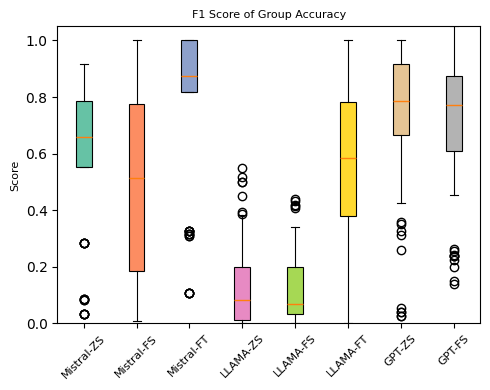

Saved: /content/FGA_boxplot.png


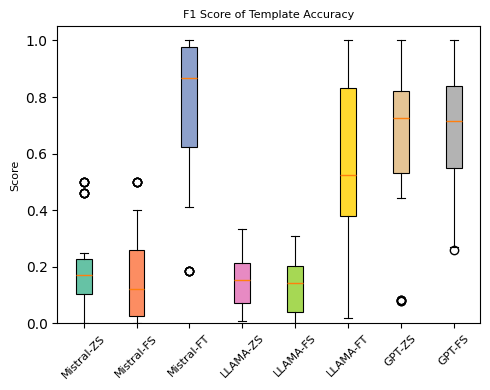

Saved: /content/FTA_boxplot.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = [
    "Parsing_Accuracy",
    "Group_Accuracy",
    "FGA",
    "FTA"
]

metric_titles = {
    "Parsing_Accuracy": "Parsing Accuracy",
    "Group_Accuracy": "Group Accuracy",
    "FGA": "F1 Score of Group Accuracy",
    "FTA": "F1 Score of Template Accuracy"
}

# Order used internally for filtering the dataframe
configs = [
    "Mistral-ZS",
    "Mistral-2S",
    "Mistral-FT",
    "LLAMA-ZS",
    "LLAMA-2S",
    "LLAMA-FT",
    "GPT-ZS",
    "GPT-2S"
]

# Labels shown only in the plots
plot_labels = [cfg.replace("-2S", "-FS") for cfg in configs]

# Create config column
results_df["Config"] = results_df["Model"] + "-" + results_df["Setting"]

# Same colors as before
colors = [
    "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"
]


def plot_metric_boxplot(results_df, metric):
    """
    Boxplot:
    X-axis: Model-Setting
    Y-axis: metric values (all datasets + runs)
    """

    data = []

    for cfg in configs:
        values = results_df[results_df["Config"] == cfg][metric].dropna().values
        data.append(values)

    plt.figure(figsize=(5, 4))

    bp = plt.boxplot(
        data,
        patch_artist=True,
        widths=0.3,
        whis=1.0
    )

    # Apply colors
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    # Thin lines (paper style)
    plt.setp(bp["boxes"], linewidth=0.8)
    plt.setp(bp["whiskers"], linewidth=0.8)
    plt.setp(bp["caps"], linewidth=0.8)
    plt.setp(bp["medians"], linewidth=1.0)

    # X axis: use plot_labels only for display
    x_pos = np.arange(len(configs))
    plt.xticks(x_pos + 1, plot_labels, rotation=45, fontsize=8)

    plt.title(metric_titles[metric], fontsize=8)
    plt.ylabel("Score", fontsize=8)

    plt.ylim(0, 1.05)

    plt.tight_layout()

    output_file = f"/content/{metric}_boxplot.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved: {output_file}")


# Generate all 4 plots
for metric in metrics:
    plot_metric_boxplot(results_df, metric)

# Box Plot for Training Exposure

/tmp/ipykernel_19443/1445302721.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
/tmp/ipykernel_19443/1445302721.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


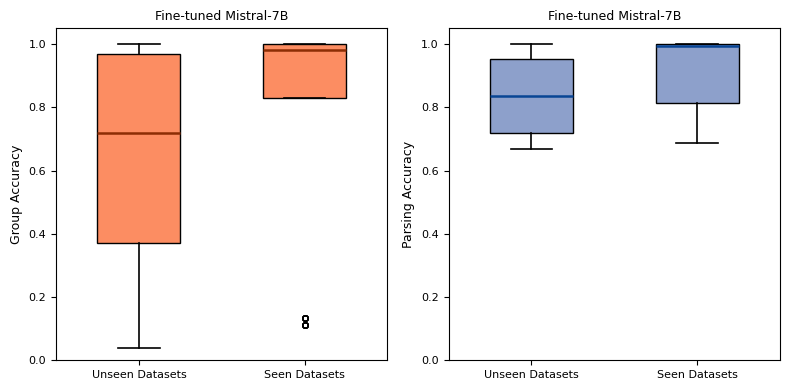

Saved: /content/Mistral_FT_Seen_New_Boxplots.png


/tmp/ipykernel_19443/1445302721.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
/tmp/ipykernel_19443/1445302721.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


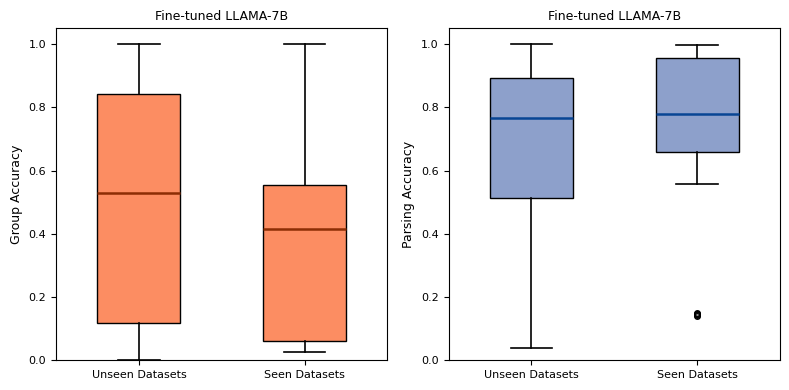

Saved: /content/LLAMA_FT_Seen_New_Boxplots.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Dataset Categories
# =====================================================

new_datasets = ["Apache", "HDFS", "HPC", "Proxifier"]

seen_datasets = [
    "BGL", "Hadoop", "HealthApp", "Linux",
    "Mac", "OpenSSH", "OpenStack", "Spark",
    "Thunderbird", "Zookeeper"
]


# =====================================================
# Collect ALL run values
# =====================================================

def collect_pipeline_values(results_df, model, setting, dataset_list, metric):

    values = []

    for dataset in dataset_list:

        dataset_values = results_df[
            (results_df["Model"] == model) &
            (results_df["Setting"] == setting) &
            (results_df["Dataset"] == dataset)
        ][metric].dropna()

        # Keep all runs
        values.extend(dataset_values.tolist())

    return np.array(values)


# =====================================================
# Main Plot Function
# =====================================================

def plot_seen_new_boxplots(results_df, model="Mistral", setting="FT"):

    # =================================================
    # Group Accuracy
    # =================================================

    new_ga = collect_pipeline_values(
        results_df,
        model,
        setting,
        new_datasets,
        "Group_Accuracy"
    )

    seen_ga = collect_pipeline_values(
        results_df,
        model,
        setting,
        seen_datasets,
        "Group_Accuracy"
    )

    # =================================================
    # Parsing Accuracy
    # =================================================

    new_pa = collect_pipeline_values(
        results_df,
        model,
        setting,
        new_datasets,
        "Parsing_Accuracy"
    )

    seen_pa = collect_pipeline_values(
        results_df,
        model,
        setting,
        seen_datasets,
        "Parsing_Accuracy"
    )

    labels = ["Unseen Datasets", "Seen Datasets"]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # =================================================
    # Group Accuracy Boxplot
    # =================================================

    bp1 = axes[0].boxplot(
        [new_ga, seen_ga],
        labels=labels,
        patch_artist=True,
        widths=0.5,

        # Elegant median line
        medianprops=dict(
            color='#8c2d04',
            linewidth=1.8
        ),

        whiskerprops=dict(
            linewidth=1.2
        ),

        capprops=dict(
            linewidth=1.2
        ),

        flierprops=dict(
            marker='o',
            markersize=4
        )
    )

    for patch in bp1['boxes']:
        patch.set_facecolor("#fc8d62")

    axes[0].set_title(
        f"Fine-tuned {model}-7B",
        fontsize=9
    )

    axes[0].set_ylabel(
        "Group Accuracy",
        fontsize=9
    )

    axes[0].set_ylim(0, 1.05)

    axes[0].tick_params(
        axis="x",
        labelsize=8
    )

    axes[0].tick_params(
        axis="y",
        labelsize=8
    )

    # =================================================
    # Parsing Accuracy Boxplot
    # =================================================

    bp2 = axes[1].boxplot(
        [new_pa, seen_pa],
        labels=labels,
        patch_artist=True,
        widths=0.5,

        # Elegant median line
        medianprops=dict(
            color='#084594',
            linewidth=1.8
        ),

        whiskerprops=dict(
            linewidth=1.2
        ),

        capprops=dict(
            linewidth=1.2
        ),

        flierprops=dict(
            marker='o',
            markersize=4
        )
    )

    for patch in bp2['boxes']:
        patch.set_facecolor("#8da0cb")

    axes[1].set_title(
        f"Fine-tuned {model}-7B",
        fontsize=9
    )

    axes[1].set_ylabel(
        "Parsing Accuracy",
        fontsize=9
    )

    axes[1].set_ylim(0, 1.05)

    axes[1].tick_params(
        axis="x",
        labelsize=8
    )

    axes[1].tick_params(
        axis="y",
        labelsize=8
    )

    plt.tight_layout()

    output_file = (
        f"/content/{model}_{setting}_Seen_New_Boxplots.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_file}")


# =====================================================
# Usage Examples
# =====================================================

plot_seen_new_boxplots(
    results_df,
    model="Mistral",
    setting="FT"
)

plot_seen_new_boxplots(
    results_df,
    model="LLAMA",
    setting="FT"
)

# Line Graph for Template Size

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bucket_order = ["xxxs", "xxs", "xs", "s", "m", "l", "xl", "xxl", "xxxl"]

setting_order = ["ZS", "2S", "FT"]

setting_labels = {
    "ZS": "Zero-shot",
    "2S": "Few-shot",
    "FT": "Fine-tuned"
}

setting_colors = {
    "ZS": "#66c2a5",
    "2S": "#fc8d62",
    "FT": "#8da0cb"
}

setting_markers = {
    "ZS": "o",
    "2S": "s",
    "FT": "^"
}

model_titles = {
    "Mistral": "Mistral-7B",
    "LLAMA": "LLAMA-8B",
    "GPT": "GPT-5.2"
}
def collect_all_template_lengths_from_pipeline(experiment_configs, dataset_names):
    all_lengths = []

    for _, config in experiment_configs.items():
        dataset_files = config["dataset_files"]

        for dataset in dataset_names:
            for file_path, _ in dataset_files[dataset]:
                df = read_file(file_path)

                all_lengths.extend(
                    df["EventTemplate"]
                    .astype(str)
                    .str.strip()
                    .dropna()
                    .apply(len)
                    .tolist()
                )

    return np.array(all_lengths)


def compute_global_quantile_cutoffs(all_lengths):
    q = np.quantile(
        all_lengths,
        [0.10, 0.20, 0.30, 0.40, 0.60, 0.70, 0.80, 0.90]
    )

    return {
        "q10": q[0],
        "q20": q[1],
        "q30": q[2],
        "q40": q[3],
        "q60": q[4],
        "q70": q[5],
        "q80": q[6],
        "q90": q[7],
    }


def assign_bucket(size, c):
    if size > c["q90"]:
        return "xxxl"
    elif size > c["q80"]:
        return "xxl"
    elif size > c["q70"]:
        return "xl"
    elif size > c["q60"]:
        return "l"
    elif size > c["q40"]:
        return "m"
    elif size > c["q30"]:
        return "s"
    elif size > c["q20"]:
        return "xs"
    elif size > c["q10"]:
        return "xxs"
    else:
        return "xxxs"

def split_file_by_bucket(file_path, cutoffs):
    df = read_file(file_path).copy()

    df["gt_size"] = df["EventTemplate"].astype(str).str.strip().apply(len)
    df["SizeBucket"] = df["gt_size"].apply(lambda x: assign_bucket(x, cutoffs))

    bucket_files = {}

    for bucket in bucket_order:
        bucket_df = df[df["SizeBucket"] == bucket].copy()

        temp_file = file_path.replace(".csv", f"_{bucket}_temp.csv")
        bucket_df.to_csv(temp_file, index=False)

        bucket_files[bucket] = temp_file

    return bucket_files

def aggregate_setting_by_bucket_using_pipeline(
    dataset_files,
    dataset_names,
    metric_name,
    cutoffs
):
    all_dataset_means = {b: [] for b in bucket_order}

    for dataset in dataset_names:
        variation_file = f"/content/{dataset}.xlsx"

        run_values = {b: [] for b in bucket_order}

        for file_path, pred_col in dataset_files[dataset]:
            bucket_files = split_file_by_bucket(file_path, cutoffs)

            for bucket in bucket_order:
                bucket_file = bucket_files[bucket]

                bucket_df = read_file(bucket_file)

                if len(bucket_df) == 0:
                    run_values[bucket].append(0.0)
                    continue

                if metric_name == "Parsing_Accuracy":
                    value = calculate_parsing_accuracy(
                        prediction_file=bucket_file,
                        variation_file=variation_file,
                        pred_col=pred_col,
                        event_col="EventTemplate",
                        gt_col="GT Template"
                    )

                elif metric_name == "Group_Accuracy":
                    value, _ = calculate_group_accuracy(
                        prediction_file=bucket_file,
                        variation_file=variation_file,
                        pred_col=pred_col,
                        event_col="EventTemplate",
                        gt_col="GT Template"
                    )

                else:
                    raise ValueError("metric_name must be Parsing_Accuracy or Group_Accuracy")

                run_values[bucket].append(value)

        for bucket in bucket_order:
            all_dataset_means[bucket].append(np.mean(run_values[bucket]))

    means = [np.mean(all_dataset_means[b]) for b in bucket_order]

    return means


def plot_model_metric_line_graph(
    model,
    metric_name,
    ylabel,
    cutoffs,
    output_dir="/content"
):
    x = np.arange(len(bucket_order))

    plt.figure(figsize=(7, 5))

    for setting in setting_order:
        config_name = f"{model}_{setting}"

        if config_name not in experiment_configs:
            continue

        dataset_files = experiment_configs[config_name]["dataset_files"]

        means = aggregate_setting_by_bucket_using_pipeline(
            dataset_files=dataset_files,
            dataset_names=dataset_names,
            metric_name=metric_name,
            cutoffs=cutoffs
        )

        plt.plot(
            x,
            means,
            marker=setting_markers[setting],
            linewidth=2,
            color=setting_colors[setting],
            label=setting_labels[setting]
        )

    plt.xticks(x, bucket_order, fontsize=8)
    plt.yticks(fontsize=8)
    plt.ylim(0, 1.05)

    plt.xlabel("Template Size Buckets", fontsize=9)
    plt.ylabel(ylabel, fontsize=9)
    plt.title(model_titles[model], fontsize=9)

    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_file = f"{output_dir}/{model}_{metric_name}_Template_Size_LinePlot.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    print(f"Saved: {output_file}")



Global bucket cutoffs: {'q10': np.float64(19.0), 'q20': np.float64(23.0), 'q30': np.float64(32.0), 'q40': np.float64(40.0), 'q60': np.float64(41.0), 'q70': np.float64(45.0), 'q80': np.float64(49.0), 'q90': np.float64(63.0)}


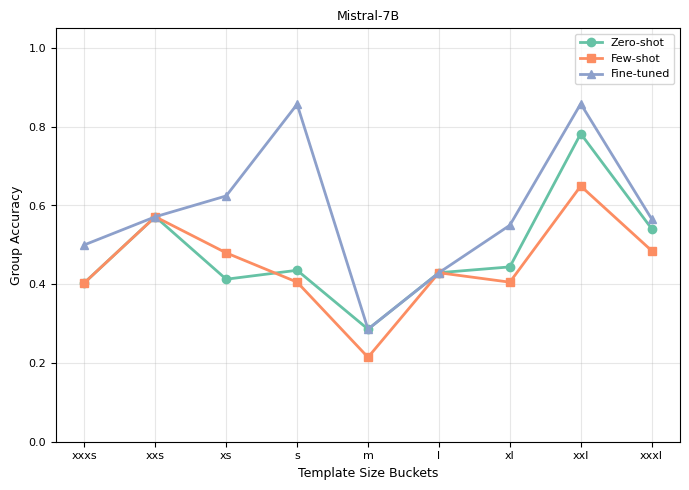

Saved: /content/Mistral_Group_Accuracy_Template_Size_LinePlot.png


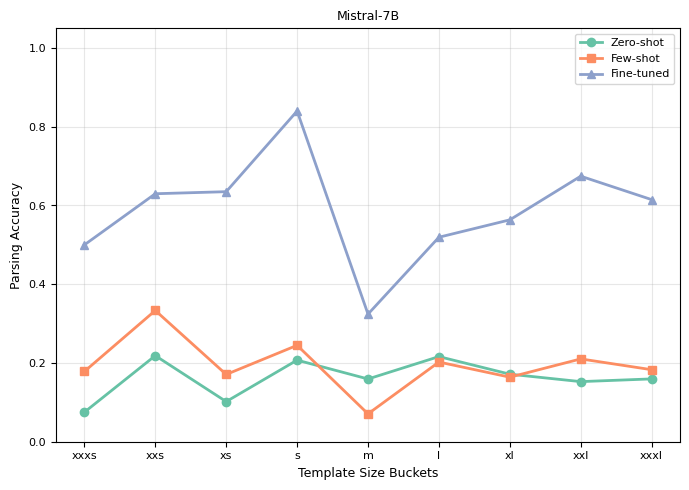

Saved: /content/Mistral_Parsing_Accuracy_Template_Size_LinePlot.png


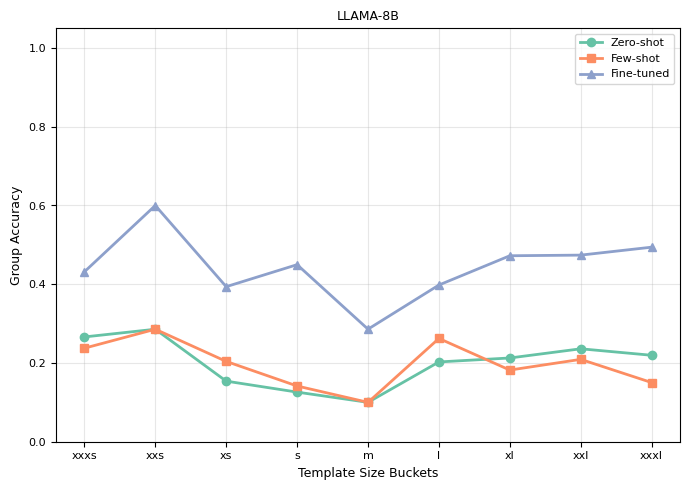

Saved: /content/LLAMA_Group_Accuracy_Template_Size_LinePlot.png


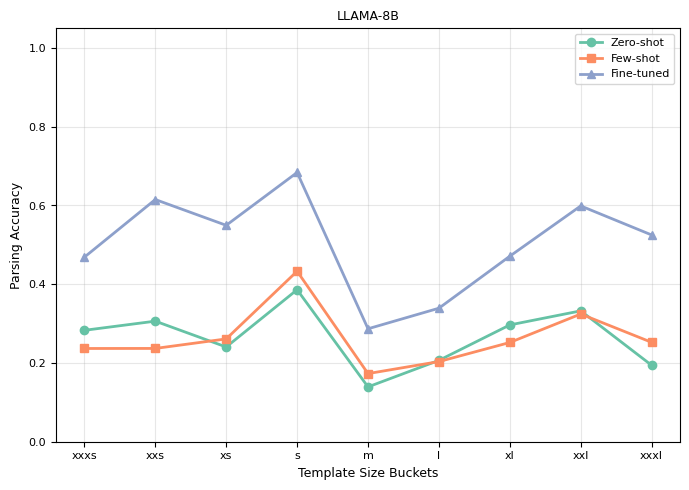

Saved: /content/LLAMA_Parsing_Accuracy_Template_Size_LinePlot.png


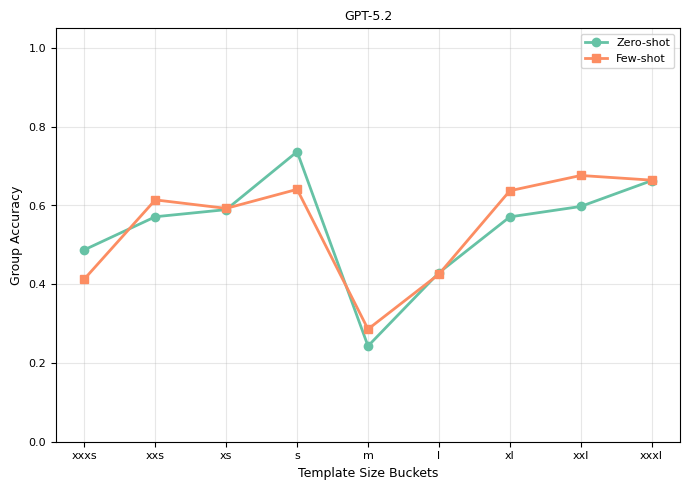

Saved: /content/GPT_Group_Accuracy_Template_Size_LinePlot.png


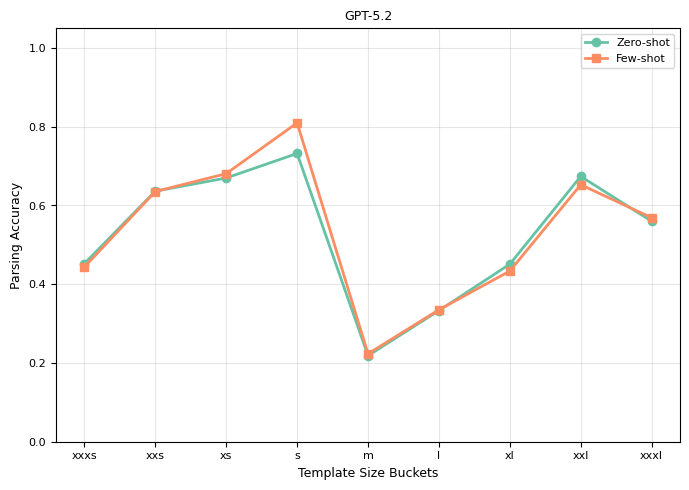

Saved: /content/GPT_Parsing_Accuracy_Template_Size_LinePlot.png


In [ ]:
all_lengths = collect_all_template_lengths_from_pipeline(
    experiment_configs=experiment_configs,
    dataset_names=dataset_names
)

global_cutoffs = compute_global_quantile_cutoffs(all_lengths)

print("Global bucket cutoffs:", global_cutoffs)

for model in ["Mistral", "LLAMA", "GPT"]:
    plot_model_metric_line_graph(
        model=model,
        metric_name="Group_Accuracy",
        ylabel="Group Accuracy",
        cutoffs=global_cutoffs
    )

    plot_model_metric_line_graph(
        model=model,
        metric_name="Parsing_Accuracy",
        ylabel="Parsing Accuracy",
        cutoffs=global_cutoffs
    )